# Niche vector comparison: V1–V4

**Experiment** (inspired by Pentimalli et al. NSCL paper):

For each cell, its spatial neighborhood defines a **niche** via the **cell-type composition vector**  
(fraction of each cell type among `k` spatial neighbors — exactly what the paper uses to cluster niches).

We compare four neighborhood embeddings against that ground truth:

| Vector | What it encodes | Moment |
|--------|----------------|--------|
| **V1 — mean PCA** | Mean of neighbors' `X_pca` | 1st moment, continuous |
| **V2 — COVET** | Covariance of neighbors' `X_pca`, PCA-reduced | 2nd moment, continuous |
| **V3 — soft-cluster avg** | Mean of neighbors' soft prototype assignments | 1st moment, discretized |
| **V4 — concat(V1, V2)** | Variance-balanced concat of V1 and V2 | 1st + 2nd moment (theoretically best) |

**V4 rationale**: V1 captures *where* neighbors are in PCA space (mean = 1st moment).  
V2 captures *how spread out* they are (covariance = 2nd moment).  
Together they encode the full distribution up to 2nd order — ideally matching composition better than either alone.

**V3 rationale**: Discretizing via soft prototypes avoids the PCA averaging problem  
(averaging PCA can cancel out opposing cell types). Instead, each cell votes over a shared vocabulary.

**Three metrics** relative to composition vector as ground truth:
1. **kNN label purity** — k-means cluster composition → labels; fraction of kNN in rep-space sharing same label
2. **Composition kNN Jaccard** — Jaccard overlap between kNN-in-composition and kNN-in-rep-space
3. **Composition cosine similarity** — cosine similarity between composition profiles of kNN-in-rep-space

## Setup

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
!pip install -q faiss-gpu-cu12 SEACells scarches scib-metrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.3/102.3 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 1.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ibis-framework 9.5.0 requires toolz<1,>=0.11, but you have toolz 1.1.0 which is incompatible.


In [13]:
%run /content/drive/MyDrive/codes/interpretable-prototype/notebooks/nb_setup.py

nb_setup done. Available: get_trainer, run_mc_task, fig_*, LAMBDA_PROTO_UMAP, LAMBDA_PROTO_UMAP_PRECON, LAMBDA_PARAM_UMAP, LAMBDA_RECON_ONLY, train_sure, eval_sure_task1/2/3
Configs: {'LAMBDA_PROTO_UMAP': {'lambda_umap': 1, 'lambda_swav': 0, 'lambda_kl': 0, 'lambda_recon': 0, 'lambda_proto_recon': 0.0, 'umap_similarity': 'proto'}, 'LAMBDA_PARAM_UMAP': {'lambda_umap': 1, 'lambda_swav': 0, 'lambda_kl': 0, 'lambda_recon': 0, 'lambda_proto_recon': 0.0, 'umap_similarity': 'embedding'}, 'LAMBDA_RECON_ONLY': {'lambda_umap': 0, 'lambda_swav': 0, 'lambda_kl': 0, 'lambda_recon': 1, 'lambda_proto_recon': 0.0}}


## Config

In [14]:
import os

DATA_PATH    = os.path.join(os.environ['DATA_DIR'], 'spatial/NSCLC_3D_section_28.h5ad')
CT_KEY       = 'celltypes'   # obs column with cell type labels
NICHE_KEY    = 'niches_3D'   # obs column with known niche labels (for reference comparison)

# ── Spatial neighborhood ────────────────────────────────────────────────────
K_SPATIAL      = 35      # kNN spatial neighbors (used when USE_RADIUS=False)
SPATIAL_RADIUS = 12.57   # coordinate units = 50 µm for NSCLC CosMx (used when USE_RADIUS=True)
USE_RADIUS     = False   # set True to switch to radius-based neighbors
BATCH_KEY      = None    # e.g. 'section' to restrict neighbors within a section

# ── Composition clustering (ground truth) ───────────────────────────────────
N_CLUSTERS   = 10   # k-means on composition vectors; paper uses 10

# ── V2: COVET ────────────────────────────────────────────────────────────────
N_PCS_COVET  = 10   # PCA dims for covariance; K_SPATIAL must be >= 3 * N_PCS_COVET

# ── V3: soft-cluster average ──────────────────────────────────────────────────
N_PROTO      = 30   # number of soft prototypes (learned from all cells' X_pca)
                    # higher = finer vocabulary; lower = more robust on small datasets

# ── V4: concat(V1, V2) ───────────────────────────────────────────────────────
CONCAT_ALPHA = 0.5  # variance weight for V1 side; 0.5 = equal; <0.5 = more COVET

# ── Evaluation ───────────────────────────────────────────────────────────────
K_EVAL       = 15   # kNN k for purity / Jaccard metrics

## Load & preprocess

In [15]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ad = sc.read_h5ad(DATA_PATH)
print(ad)
print('obs columns:', ad.obs.columns.tolist())
print('obsm keys:  ', list(ad.obsm.keys()))
print(f'\ncell types ({ad.obs[CT_KEY].nunique()}):', sorted(ad.obs[CT_KEY].unique()))
if NICHE_KEY in ad.obs.columns:
    print(f'niches ({ad.obs[NICHE_KEY].nunique()}):', sorted(ad.obs[NICHE_KEY].dropna().unique()))

AnnData object with n_obs × n_vars = 58423 × 960
    obs: 'section', 'celltypes', 'niches_3D', 'niches_2D', 'fibroblast_subclusters', 'tumor_pseudotime_rank', 'EMT_niche'
    uns: 'EMT_niche_colors', 'celltypes_colors', 'fibroblast_subclusters_colors', 'log1p', 'niches_2D_colors', 'niches_3D_colors', 'pca'
    obsm: 'X_covet', 'X_pca', 'X_umap_2D_neighbourhoods', 'X_umap_3D_neighbourhoods', 'X_umap_SCT', 'spatial'
    varm: 'PCs'
    layers: 'SCT', 'counts'
obs columns: ['section', 'celltypes', 'niches_3D', 'niches_2D', 'fibroblast_subclusters', 'tumor_pseudotime_rank', 'EMT_niche']
obsm keys:   ['X_covet', 'X_pca', 'X_umap_2D_neighbourhoods', 'X_umap_3D_neighbourhoods', 'X_umap_SCT', 'spatial']

cell types (18): ['Alveolar cells', 'B cells', 'Basal epithelial cells', 'Cycling immune cells', 'Cytotoxic T cells', 'Dendritic cells', 'Fibroblasts', 'Lymphatic endothelial cells', 'Macrophages', 'Mast cells', 'Monocytes', 'Pericytes', 'Plasma cells', 'Regulatory T cells', 'Respiratory epith

In [16]:
if 'X_pca' not in ad.obsm:
    print('Computing PCA ...')
    if ad.X.max() > 30:
        sc.pp.normalize_total(ad, target_sum=1e4)
        sc.pp.log1p(ad)
    sc.pp.highly_variable_genes(ad, n_top_genes=2000)
    sc.tl.pca(ad, n_comps=50, use_highly_variable=True)
    print('X_pca computed:', ad.obsm['X_pca'].shape)
else:
    print('X_pca already present:', ad.obsm['X_pca'].shape)

assert 'spatial' in ad.obsm, "Need ad.obsm['spatial'] (2D or 3D coordinates)"

X_pca already present: (58423, 50)


## Run comparison: V1, V2, V3, V4

In [17]:
from interpretable_ssl.evaluation.niche_composition_comparison import compare_neighborhood_reps

results = compare_neighborhood_reps(
    ad,
    k_spatial      = K_SPATIAL,
    celltype_key   = CT_KEY,
    n_clusters     = N_CLUSTERS,
    n_pcs_covet    = N_PCS_COVET,
    n_proto        = N_PROTO,
    concat_alpha   = CONCAT_ALPHA,
    k_eval         = K_EVAL,
    batch_key      = BATCH_KEY,
    spatial_radius = SPATIAL_RADIUS if USE_RADIUS else None,
    verbose        = True,
)

[compare_neighborhood_reps]  n=58423  neighbors=k=35  n_clusters=10  n_pcs_covet=10  n_proto=30  concat_alpha=0.5  k_eval=15
  step 1/6: cell-type composition vectors ...
  step 2/6: k-means(k=10) on composition ...
  step 3/6: V1 (mean PCA of neighbors) ...
  step 4/6: V2 (COVET, n_pcs=10) ...
  step 5/6: V3 (soft-cluster avg, n_proto=30) ...
  [soft_cluster_avg] adaptive tau=13.8223  n_proto=30
  step 6/6: V4 (concat V1+V2, alpha=0.5) ...
  [concat_mean_covet] V_v1=116.122  V_v2=5915.074  lambda=0.139  alpha=0.5  out_shape=(58423, 100)
  metrics ...

--- Results ---
                                             V1 mean-PCA  V2 COVET  V3 soft-cluster  V4 mean+COVET
kNN label purity (composition clusters)           0.8095    0.7134           0.7983         0.7947
composition kNN Jaccard (neighbor recovery)       0.1862    0.1353           0.1639         0.1771
composition cosine similarity                     0.9714    0.9402           0.9652         0.9687
silhouette score (composition

## Summary metrics table

In [18]:
metrics = results['metrics']
print(metrics.round(4).to_string())
print()
print("Rank per metric (1 = best):")
print(metrics.rank(axis=1, ascending=False).astype(int).to_string())
print()
mean_rank = metrics.rank(axis=1, ascending=False).mean(axis=0)
print("Mean rank (lower = better):")
print(mean_rank.sort_values().round(2))

                                             V1 mean-PCA  V2 COVET  V3 soft-cluster  V4 mean+COVET
kNN label purity (composition clusters)           0.8095    0.7134           0.7983         0.7947
composition kNN Jaccard (neighbor recovery)       0.1862    0.1353           0.1639         0.1771
composition cosine similarity                     0.9714    0.9402           0.9652         0.9687
silhouette score (composition clusters)           0.1074   -0.0312           0.0932         0.0786

Rank per metric (1 = best):
                                             V1 mean-PCA  V2 COVET  V3 soft-cluster  V4 mean+COVET
kNN label purity (composition clusters)                1         4                2              3
composition kNN Jaccard (neighbor recovery)            1         4                3              2
composition cosine similarity                          1         4                3              2
silhouette score (composition clusters)                1         4              

## Plots: bars + per-cell violins + per-cell-type breakdown

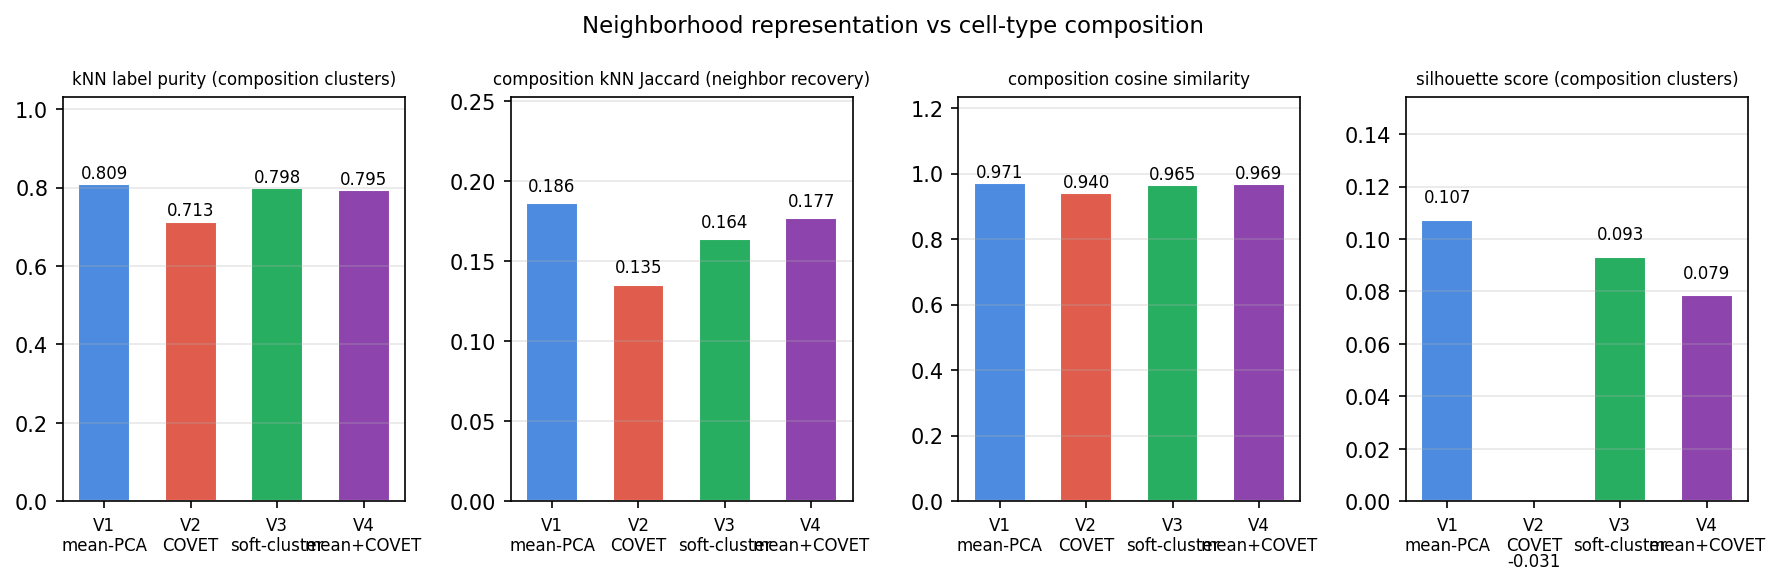

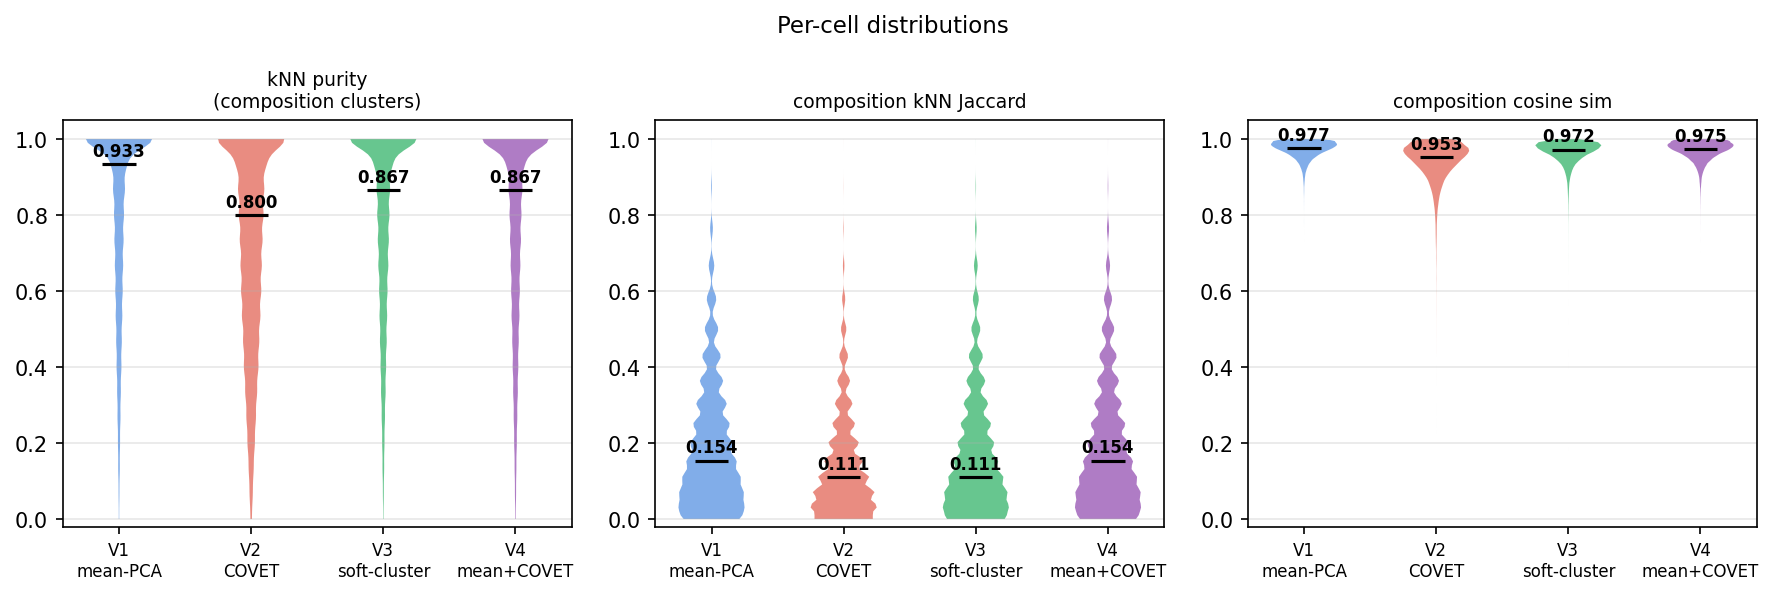

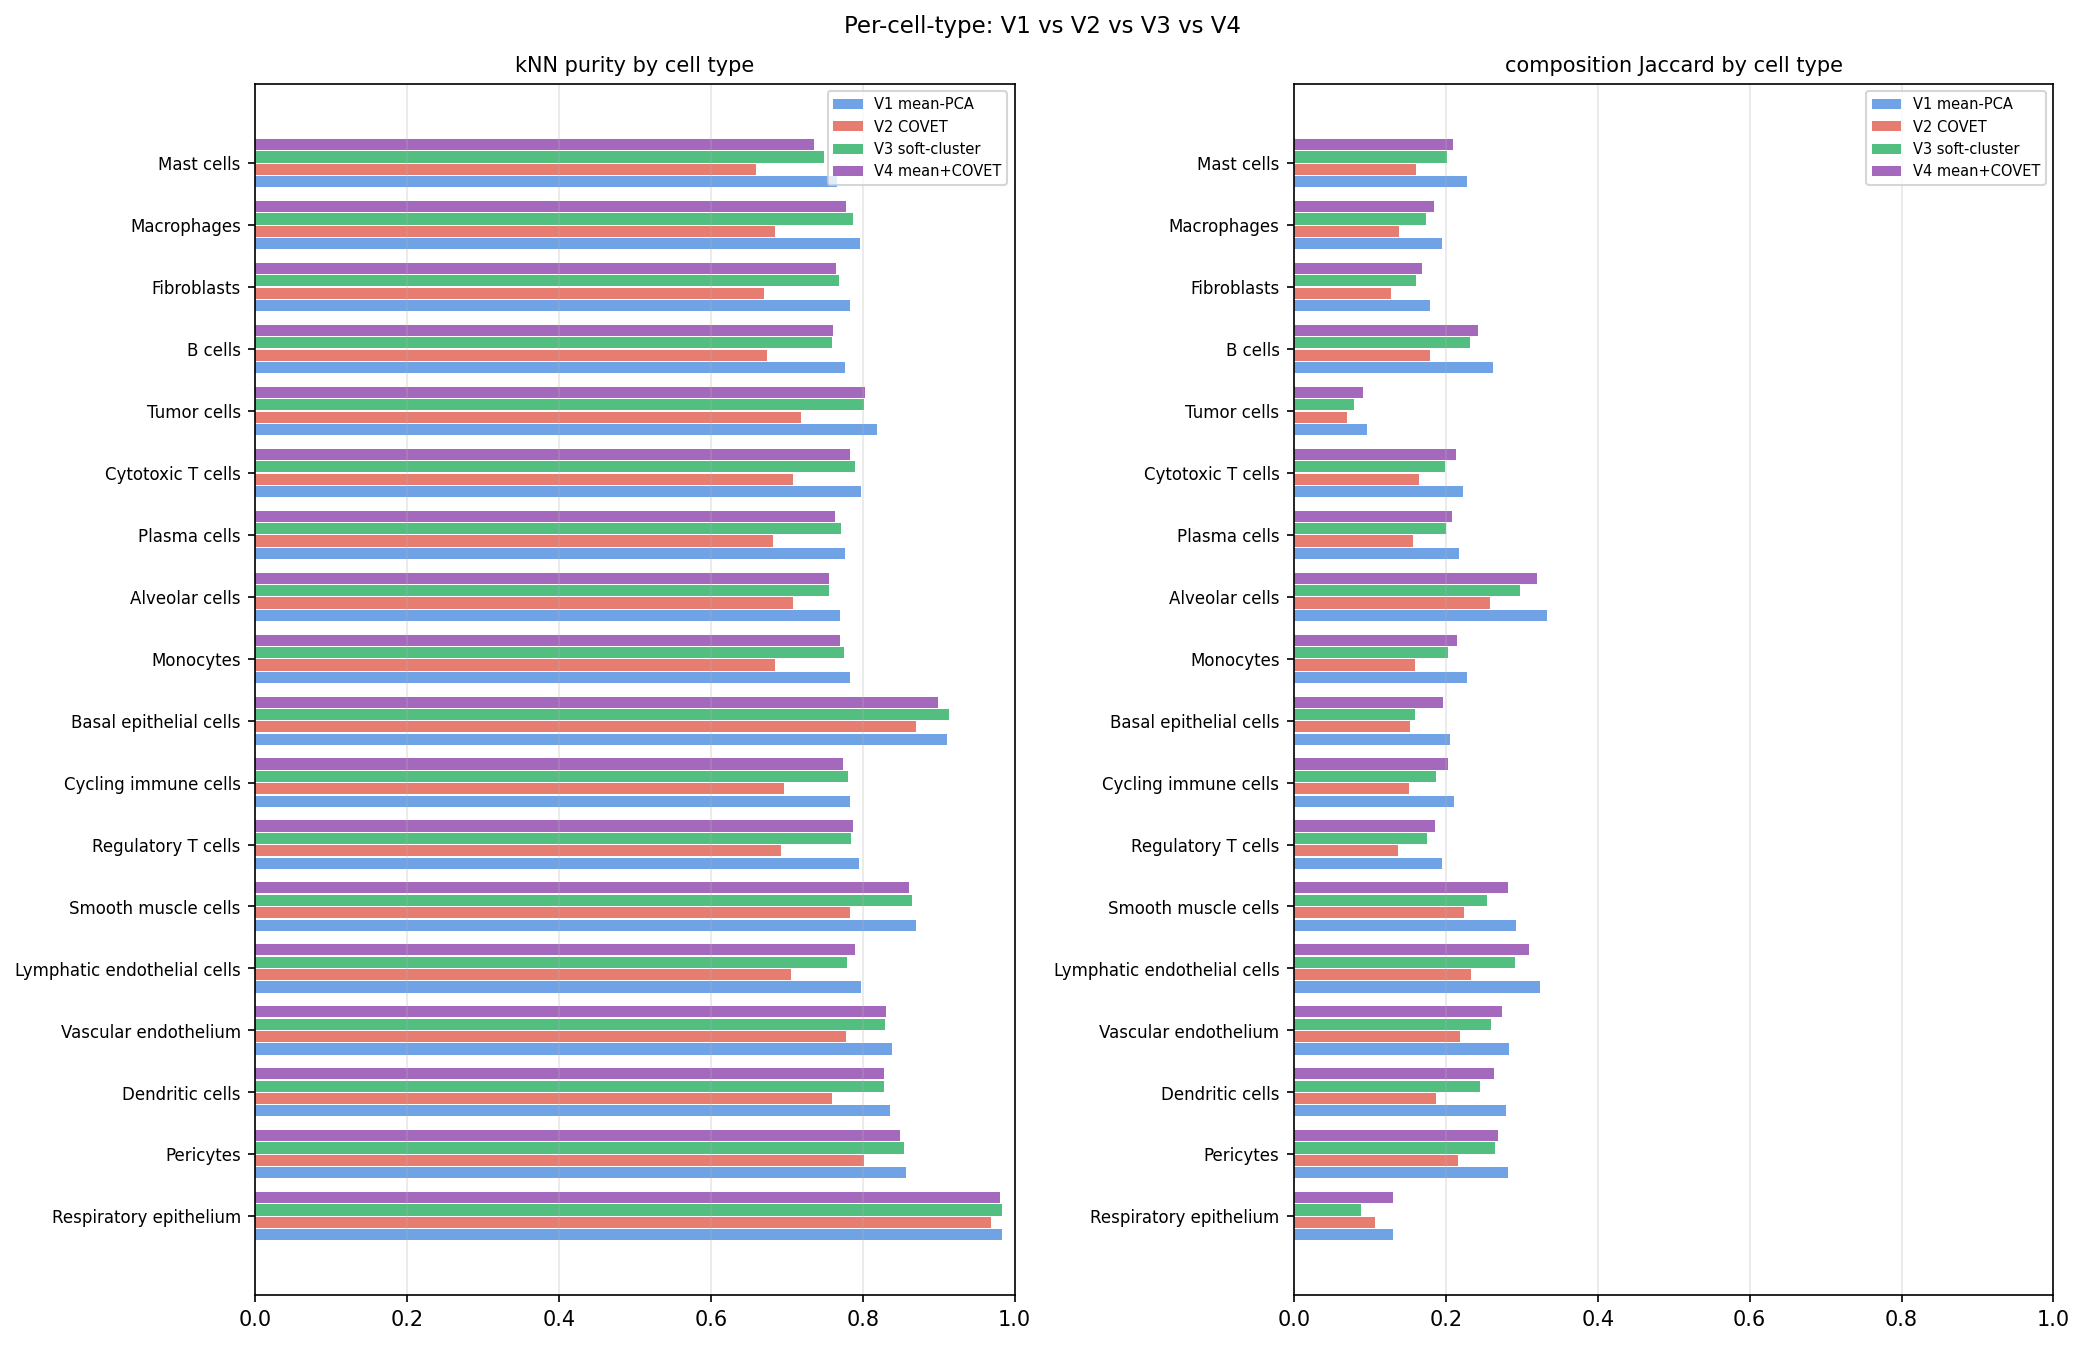

In [19]:
from interpretable_ssl.evaluation.niche_composition_comparison import plot_comparison

plot_comparison(results, ad=ad, celltype_key=CT_KEY)

## Cell-type composition clusters (replicating NSCL paper Fig 2c)

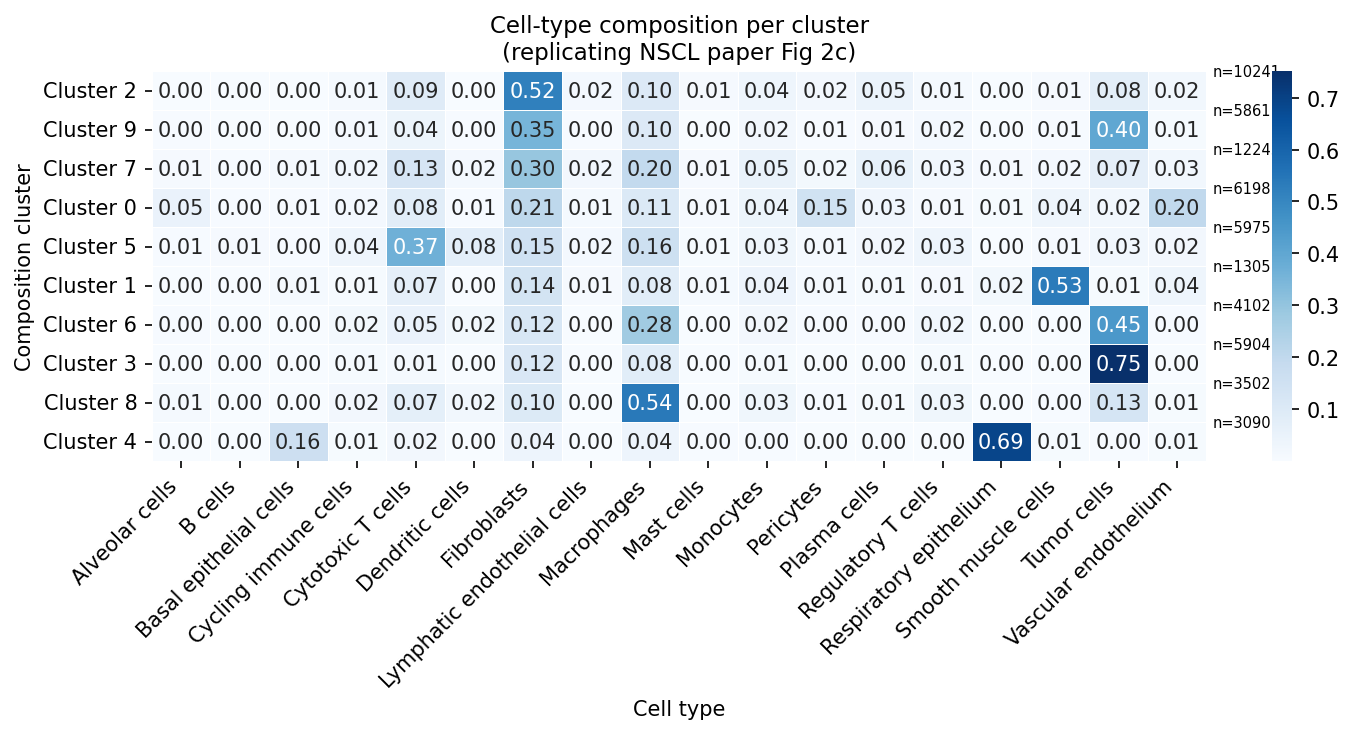

In [20]:
from interpretable_ssl.evaluation.niche_composition_comparison import plot_composition_heatmap

cluster_means = plot_composition_heatmap(results, ad, celltype_key=CT_KEY)

## Compare composition clusters to known niche labels

In [21]:
ad.obs['comp_cluster'] = results['comp_labels'].astype(str)

if NICHE_KEY in ad.obs.columns:
    ct_tab = pd.crosstab(
        ad.obs['comp_cluster'],
        ad.obs[NICHE_KEY],
        normalize='index',
    ).round(2)
    print("Composition cluster vs known niches (row-normalized):")
    print(ct_tab.to_string())

Composition cluster vs known niches (row-normalized):
niches_3D     Airways  Alveolar spaces  DC islands  Desmoplastic stroma  Excluded  Macrophage islands  Smooth muscle structures  T cell aggregates  Tumor core  Tumor surface  Vascular stroma
comp_cluster                                                                                                                                                                                  
0                0.05             0.22        0.00                 0.02      0.04                0.00                      0.03               0.06        0.00           0.00             0.59
1                0.21             0.00        0.00                 0.00      0.16                0.00                      0.61               0.00        0.00           0.00             0.02
2                0.02             0.01        0.00                 0.68      0.03                0.00                      0.01               0.07        0.00           0.04         

## UMAP: own PCA vs V1 vs V2 vs V3 vs V4

Each UMAP colored by cell type, composition cluster, and (if available) known niches.

**Key questions to read from these plots:**
- Does V4 (purple) cluster niches cleanly within cell-type clouds, better than V1/V2 alone?
- Does V3 (green, discretized) change the structure compared to V1 (blue, continuous)?

In [22]:
# Store embeddings so scanpy can run UMAP on them
for name, X_rep in results['reps'].items():
    key = name.replace(' ', '_').replace('+', 'plus')
    ad.obsm[f'X_{key}'] = X_rep

emb_map = {
    'PCA (own)': 'X_pca',
    **{name: f'X_{name.replace(" ","_").replace("+","plus")}'
       for name in results['reps']}
}

for label, key in emb_map.items():
    sc.pp.neighbors(ad, use_rep=key, n_neighbors=30, key_added=f'nbrs_{label}')
    sc.tl.umap(ad, neighbors_key=f'nbrs_{label}', min_dist=0.3)
    ad.obsm[f'X_umap_{label}'] = ad.obsm['X_umap'].copy()
    print(f'UMAP: {label}')

UMAP: PCA (own)
UMAP: V1 mean-PCA
UMAP: V2 COVET
UMAP: V3 soft-cluster
UMAP: V4 mean+COVET


In [23]:
from matplotlib.lines import Line2D

color_keys = [CT_KEY, 'comp_cluster'] + ([NICHE_KEY] if NICHE_KEY in ad.obs.columns else [])
emb_labels = list(emb_map.keys())
palette    = plt.cm.tab20.colors

n_rows = len(color_keys)
n_cols = len(emb_labels)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.5 * n_cols, 3.8 * n_rows))
if n_rows == 1:
    axes = axes[None, :]

for row_i, ck in enumerate(color_keys):
    cats = ad.obs[ck].astype(str).astype('category').cat.categories
    cmap = {c: palette[i % len(palette)] for i, c in enumerate(cats)}
    cell_colors = [cmap[str(c)] for c in ad.obs[ck]]

    for col_i, emb_label in enumerate(emb_labels):
        ax = axes[row_i, col_i]
        X2 = ad.obsm[f'X_umap_{emb_label}']
        ax.scatter(X2[:, 0], X2[:, 1], c=cell_colors, s=1, alpha=0.4, rasterized=True)
        ax.set_title(f'{emb_label}\nby {ck}', fontsize=8)
        ax.axis('off')

    handles = [Line2D([0],[0], marker='o', color='w',
                      markerfacecolor=cmap[str(c)], markersize=5, label=str(c))
               for c in cats]
    axes[row_i, -1].legend(handles=handles, fontsize=6,
                            loc='center left', bbox_to_anchor=(1, 0.5),
                            ncol=max(1, len(cats) // 18))

plt.suptitle('UMAP: PCA vs V1 vs V2 vs V3 vs V4', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

## Ablation: effect of n_proto on V3

  [soft_cluster_avg] adaptive tau=14.9571  n_proto=10
n_proto= 10  purity=0.7592  jaccard=0.0901
  [soft_cluster_avg] adaptive tau=14.2144  n_proto=20
n_proto= 20  purity=0.7958  jaccard=0.1486
  [soft_cluster_avg] adaptive tau=13.8223  n_proto=30
n_proto= 30  purity=0.7983  jaccard=0.1639
  [soft_cluster_avg] adaptive tau=13.4389  n_proto=50
n_proto= 50  purity=0.7928  jaccard=0.1732
  [soft_cluster_avg] adaptive tau=12.9752  n_proto=100
n_proto=100  purity=0.7824  jaccard=0.1767


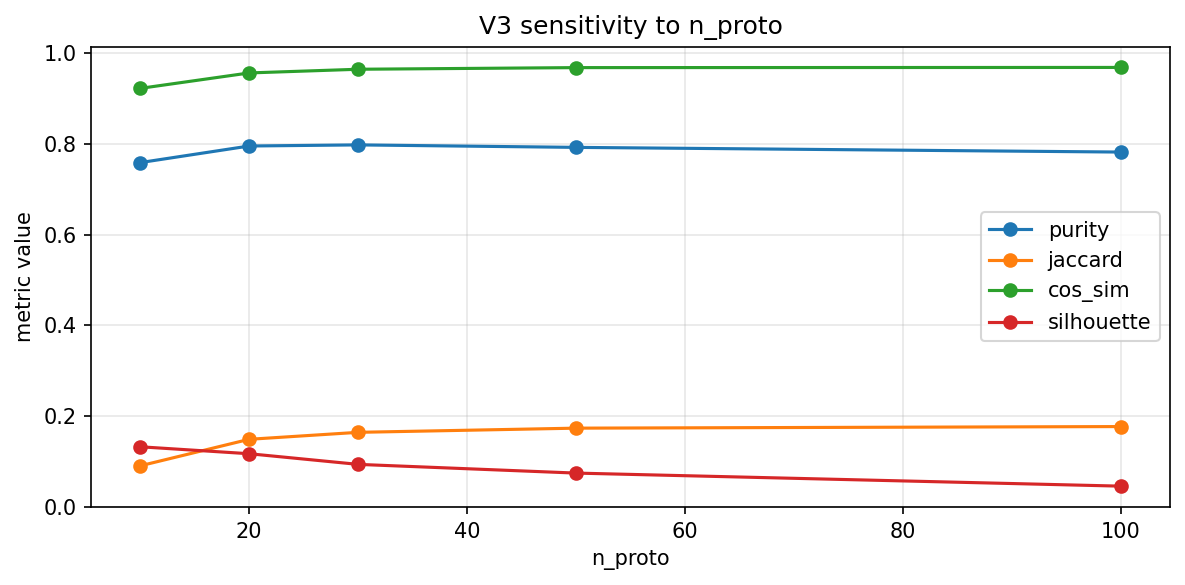

In [24]:
from interpretable_ssl.evaluation.niche_composition_comparison import (
    compute_soft_cluster_avg, _metrics_for_rep
)

# Reuse comp_df and I from results (already computed)
comp_df    = results['comp_df']
comp_labels = results['comp_labels']
comp_vecs   = comp_df.values

# Recompute I with the same neighbor settings used above
from interpretable_ssl.evaluation.niche_composition_comparison import compute_celltype_composition
_, I = compute_celltype_composition(
    ad, k=K_SPATIAL, celltype_key=CT_KEY,
    batch_key=BATCH_KEY, radius=SPATIAL_RADIUS if USE_RADIUS else None,
)

proto_sweep = [10, 20, 30, 50, 100]
proto_rows = []
for n_p in proto_sweep:
    X_v3 = compute_soft_cluster_avg(ad, I, n_proto=n_p)
    pur, jac, cos, sil = _metrics_for_rep(X_v3, comp_labels, comp_vecs, K_EVAL, 0)
    proto_rows.append({'n_proto': n_p, 'purity': pur.mean(), 'jaccard': jac.mean(),
                       'cos_sim': cos.mean(), 'silhouette': sil})
    print(f'n_proto={n_p:3d}  purity={pur.mean():.4f}  jaccard={jac.mean():.4f}')

proto_df = pd.DataFrame(proto_rows).set_index('n_proto')
proto_df.plot(marker='o', figsize=(8, 4), title='V3 sensitivity to n_proto')
plt.ylabel('metric value')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Ablation: effect of concat_alpha on V4

  [concat_mean_covet] V_v1=116.122  V_v2=5915.074  lambda=0.047  alpha=0.1  out_shape=(58423, 100)
alpha=0.10  purity=0.8073  jaccard=0.1869
  [concat_mean_covet] V_v1=116.122  V_v2=5915.074  lambda=0.081  alpha=0.25  out_shape=(58423, 100)
alpha=0.25  purity=0.8031  jaccard=0.1846
  [concat_mean_covet] V_v1=116.122  V_v2=5915.074  lambda=0.139  alpha=0.5  out_shape=(58423, 100)
alpha=0.50  purity=0.7947  jaccard=0.1771
  [concat_mean_covet] V_v1=116.122  V_v2=5915.074  lambda=0.236  alpha=0.75  out_shape=(58423, 100)
alpha=0.75  purity=0.7811  jaccard=0.1648
  [concat_mean_covet] V_v1=116.122  V_v2=5915.074  lambda=0.387  alpha=0.9  out_shape=(58423, 100)
alpha=0.90  purity=0.7616  jaccard=0.1526


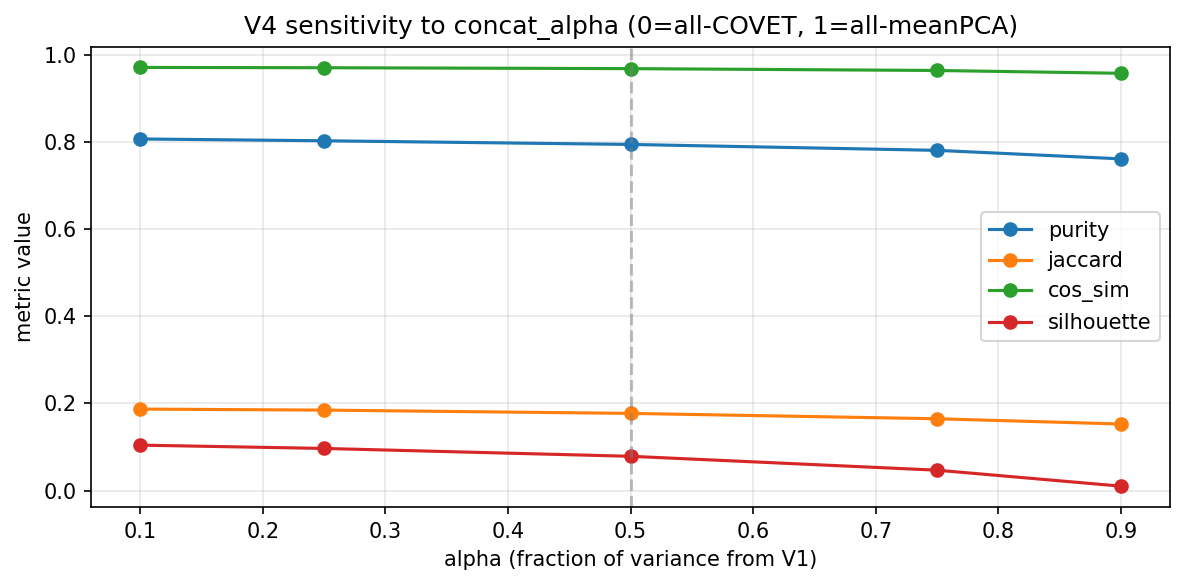

In [25]:
from interpretable_ssl.evaluation.niche_composition_comparison import compute_concat_mean_covet

X_v1 = results['reps']['V1 mean-PCA']
X_v2 = results['reps']['V2 COVET']

alpha_sweep = [0.1, 0.25, 0.5, 0.75, 0.9]
alpha_rows = []
for alpha in alpha_sweep:
    X_v4 = compute_concat_mean_covet(X_v1, X_v2, alpha=alpha)
    pur, jac, cos, sil = _metrics_for_rep(X_v4, comp_labels, comp_vecs, K_EVAL, 0)
    alpha_rows.append({'alpha': alpha, 'purity': pur.mean(), 'jaccard': jac.mean(),
                       'cos_sim': cos.mean(), 'silhouette': sil})
    print(f'alpha={alpha:.2f}  purity={pur.mean():.4f}  jaccard={jac.mean():.4f}')

alpha_df = pd.DataFrame(alpha_rows).set_index('alpha')
alpha_df.plot(marker='o', figsize=(8, 4),
              title='V4 sensitivity to concat_alpha (0=all-COVET, 1=all-meanPCA)')
plt.xlabel('alpha (fraction of variance from V1)')
plt.ylabel('metric value')
plt.axvline(0.5, color='grey', linestyle='--', alpha=0.5)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Sensitivity: vary k_spatial


=== k_spatial=30 ===
  [soft_cluster_avg] adaptive tau=13.8223  n_proto=30
  [concat_mean_covet] V_v1=120.703  V_v2=6094.906  lambda=0.139  alpha=0.5  out_shape=(58423, 100)

=== k_spatial=50 ===
  [soft_cluster_avg] adaptive tau=13.8223  n_proto=30
  [concat_mean_covet] V_v1=106.446  V_v2=5554.357  lambda=0.137  alpha=0.5  out_shape=(58423, 100)

=== k_spatial=70 ===
  [soft_cluster_avg] adaptive tau=13.8223  n_proto=30
  [concat_mean_covet] V_v1=98.279  V_v2=5260.556  lambda=0.135  alpha=0.5  out_shape=(58423, 100)

=== k_spatial=100 ===
  [soft_cluster_avg] adaptive tau=13.8223  n_proto=30
  [concat_mean_covet] V_v1=90.375  V_v2=4999.290  lambda=0.133  alpha=0.5  out_shape=(58423, 100)


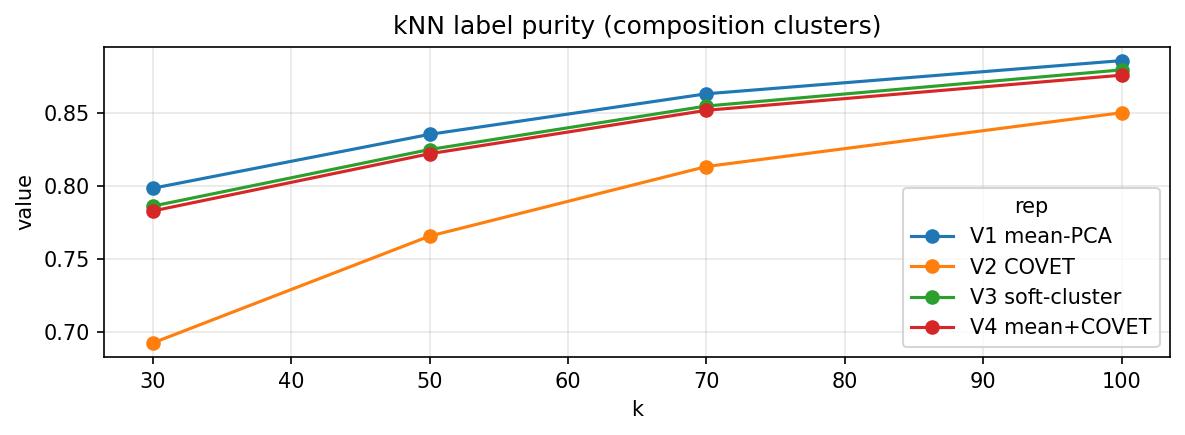

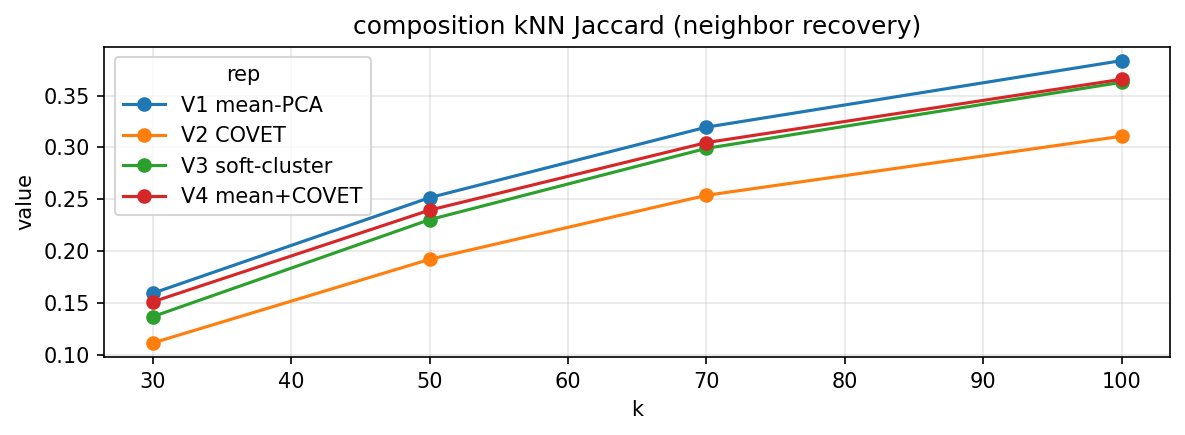

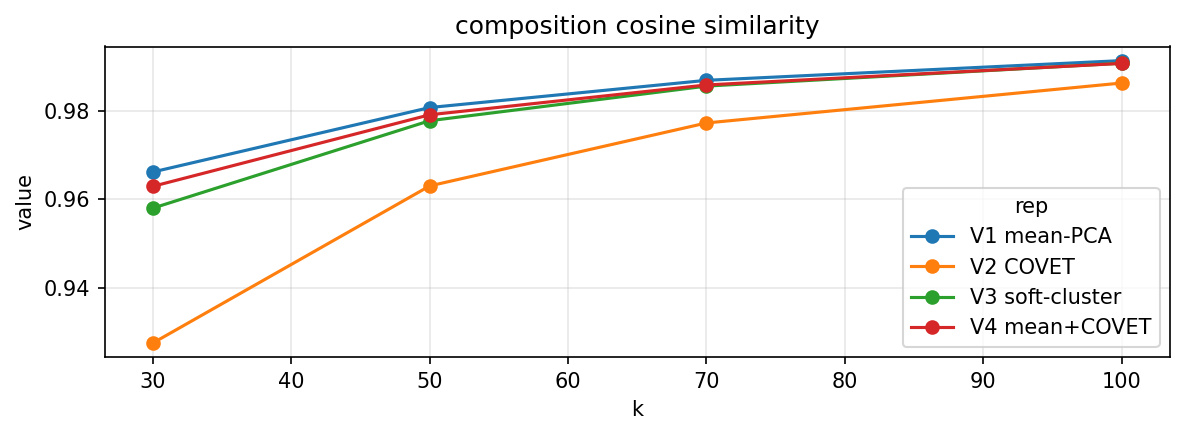

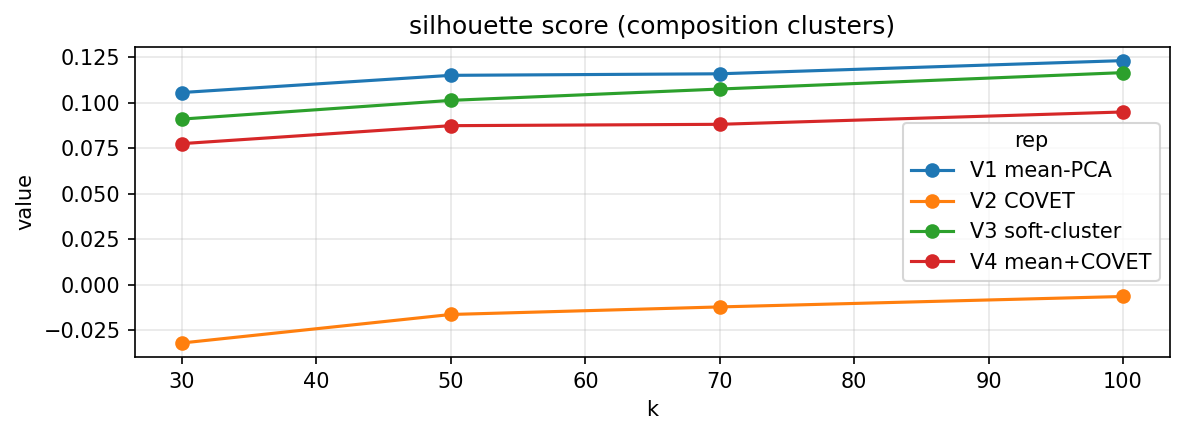

In [ ]:
k_sweep = [30, 50, 70, 100]
sweep_rows = []

for k in k_sweep:
    print(f"\n=== k_spatial={k} ===")
    res = compare_neighborhood_reps(
        ad, k_spatial=k, celltype_key=CT_KEY,
        n_clusters=N_CLUSTERS, n_pcs_covet=N_PCS_COVET,
        n_proto=N_PROTO, concat_alpha=CONCAT_ALPHA,
        k_eval=K_EVAL, batch_key=BATCH_KEY, verbose=False,
    )
    for metric_name, row in res['metrics'].iterrows():
        for rep_name, val in row.items():
            sweep_rows.append({'k': k, 'metric': metric_name, 'rep': rep_name, 'value': val})

sweep_df = pd.DataFrame(sweep_rows)
for metric_name in sweep_df['metric'].unique():
    sub = sweep_df[sweep_df['metric'] == metric_name]
    pivot = sub.pivot(index='k', columns='rep', values='value')
    pivot.plot(marker='o', figsize=(8, 3), title=metric_name)
    plt.ylabel('value')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()